In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt


from models import tree_random_normal_like, ModelIdentificationDecoder, Simformer, EDM

In [4]:
class cond:
    def __init__(self, idx, true_fun, false_fun):
        self.idx = idx
        self.true_fun = true_fun
        self.false_fun = false_fun

    def __call__(self, mask, *args, **kwargs):
        return jax.lax.cond(mask[self.idx], self.true_fun, self.false_fun, *args, **kwargs)
    
class atomic(cond):
    def __init__(self, idx, true_fun, false_fun = lambda x: x):
        super().__init__(idx, true_fun, false_fun)
    
class where:
    def __init__(self, idx):
        self.idx = idx
    
    def __call__(self, mask, x, y = None):
        return jnp.where(mask[self.idx], x, y)


class affine_compartment:
    def __init__(self, idx):
        self.idx = idx

    def init_params(self, key):
        key1, key2 = jax.random.split(key)
        scale = jax.random.normal(key1, (1,))
        bias = jax.random.normal(key2, (1,))
        return (scale, bias)

    def __call__(self, mask, params, x):
        scale, bias = params[self.idx]
        def true_fun(x):
            return scale * x + bias
        def false_fun(x):
            return x
        
        return jax.lax.cond(mask[self.idx], true_fun, false_fun, x)



In [5]:
l1 = affine_compartment(0)
l2 = affine_compartment(1)
l3 = affine_compartment(2)
l4 = affine_compartment(3)
l5 = affine_compartment(4)

activation1 = atomic(5, jax.nn.relu)
activation2 = atomic(6, jax.nn.sigmoid)
activation3 = atomic(7, jax.nn.tanh)
activation4 = atomic(8, jax.nn.relu)
activation5 = atomic(9, jax.nn.sigmoid)

l1_2 = affine_compartment(10)
l2_2 = affine_compartment(11)
l3_2 = affine_compartment(12)
l4_2 = affine_compartment(13)
l5_2 = affine_compartment(14)

activation1_2 = atomic(15, jax.nn.relu)
activation2_2 = atomic(16, jax.nn.sigmoid)
activation3_2 = atomic(17, jax.nn.tanh)
activation4_2 = atomic(18, jax.nn.relu)
activation5_2 = atomic(19, jax.nn.sigmoid)

l_noise = affine_compartment(20)


PARAMS_IDX = [0, 1, 2, 3, 4, 10, 11, 12, 13, 14, 20]

model_params = {0: l1.init_params(jax.random.PRNGKey(0)),
          1: l2.init_params(jax.random.PRNGKey(1)),
          2: l3.init_params(jax.random.PRNGKey(2)),
          3: l4.init_params(jax.random.PRNGKey(3)),
          4: l5.init_params(jax.random.PRNGKey(4)),
          10: l1_2.init_params(jax.random.PRNGKey(10)),
          11: l2_2.init_params(jax.random.PRNGKey(11)),
          12: l3_2.init_params(jax.random.PRNGKey(12)),
          13: l4_2.init_params(jax.random.PRNGKey(13)),
          14: l5_2.init_params(jax.random.PRNGKey(14)),
          20: l_noise.init_params(jax.random.PRNGKey(20))
}


def prior_model_params(rng):
    return tree_random_normal_like(rng,model_params)
    

def f(mask, params, x, rng):
    h1 = l1(mask, params, x)
    h2 = l2(mask, params, x)
    h3 = l3(mask, params, x)
    h4 = l4(mask, params, x)
    h5 = l5(mask, params, x)

    act1 = activation1(mask, h1)
    act2 = activation2(mask, h2)
    act3 = activation3(mask, h3)
    act4 = activation4(mask, h4)
    act5 = activation5(mask, h5)

    h1_2 = l1_2(mask, params, act1)
    h2_2 = l2_2(mask, params, act2)
    h3_2 = l3_2(mask, params, act3)
    h4_2 = l4_2(mask, params, act4)
    h5_2 = l5_2(mask, params, act5)

    out1 = activation1_2(mask, h1_2)
    out2 = activation2_2(mask, h2_2)
    out3 = activation3_2(mask, h3_2)
    out4 = activation4_2(mask, h4_2)
    out5 = activation5_2(mask, h5_2)

    eps = jax.random.normal(rng, (1,)) * 0.1
    out_noise = l_noise(mask, params, eps)


    return out1 + out2 + out3 + out4 + out5 + out_noise






2024-11-07 13:48:21.048174: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.5 which is older than the PTX compiler version 12.6.77. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [6]:
key = jax.random.PRNGKey(9)
component_mask = jax.random.bernoulli(key, p = 0.5, shape = (21,))
model_params = prior_model_params(jax.random.PRNGKey(2))
rng = jax.random.PRNGKey(3)
x = jnp.ones((1,))  


xs = jnp.linspace(-10, 10, 100).reshape(-1,1)
rngs = jax.random.split(rng, 100)
ys = jax.vmap(f, in_axes=(None,None,0,0))(component_mask, model_params, xs, rngs)

In [ ]:
def generate_data(key, num_samples=100):
    rng_comp, rng_params, rng_data = jax.random.split(key, 3)
    component_mask = jax.random.bernoulli(rng_comp, p = 0.5, shape = (21,))
    model_params = prior_model_params(rng_params)
    rng_x, rng_y = jax.random.split(rng_data)
    xs = jax.random.normal(rng_x, (num_samples,1)) * 2
    rngs_ys = jax.random.split(rng_y, num_samples)
    ys = jax.vmap(f, in_axes=(None,None,0,0))(component_mask, model_params, xs, rngs_ys)
    data = jnp.concatenate([xs, ys], axis = 1)

    return component_mask, model_params, data

In [8]:
component_mask, model_params, data = generate_data(jax.random.PRNGKey(9), 100)

component_mask.shape, data.shape

((21,), (100, 2))

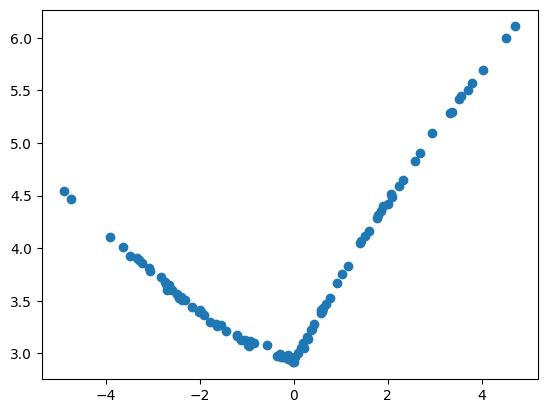

In [75]:
plt.plot(data[:,0], data[:,1], 'o')

In [215]:
def flatten_model_params(model_params):
    idx = list(model_params.keys())
    params = list(model_params.values())
    params = [jnp.concatenate(p) for p in params]
    flat_params, unflatten = jax.flatten_util.ravel_pytree(params)
    _unflatten = lambda flat_params: unflatten(flat_params.reshape(-1))
    return list(range(len(idx))), flat_params.reshape(1, -1, 1), _unflatten

In [216]:
node_ids, vals, unflatten = flatten_model_params(model_params)

In [272]:

from flax import nnx

class PyTreeTokenizer(nnx.Module, experimental_pytree=True):
    def __init__(self, unflatten, encode_nets, decode_nets ,id_dim=25, cond_dim=10, rngs=None):
        self.unflatten = unflatten
        self.encode_nets = encode_nets
        self.decode_nets = decode_nets  
        self.embed_id = nnx.Embed(len(self.encode_nets), id_dim, rngs=rngs)

    def __call__(self, x, node_ids, condition_mask=None, context=None, **kwargs):
        x = jax.vmap(self.unflatten)(x)
        net_subs = [self.encode_nets[i] for i in node_ids]
        x = jax.tree_util.tree_map(lambda x, net: net(x).reshape(x.shape[0], -1, 25), x, net_subs)
        val_embeding = jnp.concatenate(list(x), axis=-2)

        ids = self.embed_id(jnp.array(node_ids, dtype=jnp.int32))
        while len(ids.shape) < len(val_embeding.shape):
            ids = jnp.expand_dims(ids, axis=0)

        ids = jnp.repeat(ids, val_embeding.shape[0], axis=0)
        
        embeddings = jnp.concatenate([val_embeding, ids], axis=-1)
        if context is not None:
            print(context.sum())
            embeddings = embeddings + context * 100000000
        
        return embeddings
    
    def decode(self, h, node_ids, condition_mask=None, context=None, **kwargs):
        hs = jnp.split(h, h.shape[-2], axis=-2)
        print(h.shape)
        net_subs = [self.decode_nets[i] for i in node_ids]
        x = jax.tree_util.tree_map(lambda x, net: net(x), hs, net_subs)
        out =  jnp.concatenate(x, axis=-2).reshape(-1, 22, 1)
        return out
    



In [281]:
from typing import Any
from models import ModelIdentificationDecoder, Simformer, EDM, ScalarTokenizer, VectorTokenizer 
from probjax.nn import DeepSet, MLP


NUM_TRAINABLE = 22
TRAINABLE_IDX = list(model_params.keys())

trial_net = MLP([2,50,100], rngs=nnx.Rngs(123))
summary_net = MLP([100,50,50], rngs=nnx.Rngs(124))
embedding_net = DeepSet(trial_net, summary_net)
model_decoder = ModelIdentificationDecoder(50, 50, num_layers=4, rngs=nnx.Rngs(0), context_net=embedding_net)
encode_nets = [nnx.Linear(2, 25, rngs=nnx.Rngs(i)) for i in range(len(node_ids))]
decode_nets = [nnx.Linear(50, 2, rngs=nnx.Rngs(i+123)) for i in range(len(node_ids))]
tokenizer =  PyTreeTokenizer(unflatten, encode_nets, decode_nets, rngs=nnx.Rngs(235135))

param_decoder = EDM(Simformer(tokenizer, num_layers=2, rngs=nnx.Rngs(42)))

params1 = nnx.state(model_decoder, nnx.Param)
params2 = nnx.state(param_decoder, nnx.Param)
params = (params1, params2)

In [282]:
logits, latents = model_decoder(component_mask, data, return_latents=True)

In [283]:
latents.shape

(21, 50)

In [284]:
node_ids, vals, unflatten = flatten_model_params(model_params)
t = jnp.ones((1, 1,1))

param_decoder(t, vals, node_ids=node_ids, condition_mask=None, context=latents[TRAINABLE_IDX,:].reshape(1, -1, 50))

5.722046e-06
(1, 11, 50)


Array([[[ 0.232],
        [-0.493],
        [ 0.026],
        [ 0.295],
        [-0.471],
        [-0.583],
        [-0.664],
        [ 0.341],
        [-0.66 ],
        [-0.893],
        [ 0.047],
        [ 1.09 ],
        [ 1.675],
        [-0.138],
        [-0.031],
        [-0.813],
        [ 0.99 ],
        [ 0.271],
        [-1.893],
        [-0.197],
        [ 0.752],
        [ 1.585]]], dtype=float32)

In [257]:
from probjax.nn.loss_fn.denoising import build_time_dependent_denoising_loss

def mean_fn(t, x):
    return x

def std_fn(t, x):
    return param_decoder.std_fn(t) 

denoiser_loss_fn = build_time_dependent_denoising_loss(param_decoder, mean_fn=mean_fn, std_fn=std_fn, weight_fn=param_decoder.weight_fn, axis=-2)

In [285]:
import optax


optimizer = optax.adam(5e-4)


train_num_samples = [100]

def loss_fn(params, key):
    params1, params2 = params
    nnx.update(model_decoder, params1)
    l = 0.
    for n in train_num_samples:
        batch_size = 100
        key, subkey = jax.random.split(key)
        key_data, key_dsm = jax.random.split(subkey)
        keys = jax.random.split(key_data, (batch_size,))
        component_mask, params_model, data = jax.vmap(lambda k: generate_data(k, n))(keys)
        
        # Model identification loss
        logits_comp, latents = model_decoder(component_mask, context=data, return_latents=True)
        loss1 = jnp.mean(optax.sigmoid_binary_cross_entropy(logits_comp, component_mask))

        # Parameter prediction loss
        # Get trainable parameters
        model_params_flat = jnp.concatenate([jnp.concat(params_model[i]) for i in params_model], axis=-1).reshape(-1,NUM_TRAINABLE,1)
        latents_subset = latents[:, TRAINABLE_IDX, :]
        mask_subset = component_mask[:, TRAINABLE_IDX]

        attention_mask = mask_subset[:, :, None] & mask_subset[:, None, :]
        attention_mask = jnp.logical_or(attention_mask, jnp.eye(len(TRAINABLE_IDX), dtype=jnp.bool_))

        key_time, key_loss = jax.random.split(key_dsm)
        logt = jax.random.normal(key_time, shape=(batch_size, 1,1)) * 1.2 - 1.2
        node_id = list(range(len(TRAINABLE_IDX)))
        t = jnp.exp(logt) + 0.0001

        # loss_mask = mask_subset.reshape(-1,1)
        # loss_mask = mask_subset.repeat(2, axis=-1).reshape(-1,NUM_TRAINABLE,1)
        print(model_params_flat.shape, t.shape, latents_subset.shape)
        emebddings = model_decoder.context_embedding(data)
        loss2 = denoiser_loss_fn(params2, t, model_params_flat, node_ids=node_id, condition_mask=None, context = emebddings.reshape(-1,1, 50), rng=key_loss)



        # Weight loss for equal importance
        l += loss2
    return l / len(train_num_samples)


@jax.jit
def update(params, key, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, key)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [286]:
loss_fn(params, jax.random.PRNGKey(0))

(100, 22, 1) (100, 1, 1) (100, 11, 50)
33065.64
(100, 11, 50)


Array(43.443, dtype=float32)

In [287]:

key = jax.random.PRNGKey(0)
opt_state = optimizer.init(params)    

In [289]:

for i in range(2_000):
    key, subkey, key2 = jax.random.split(key, 3)
    loss, params, opt_state = update(params,subkey, opt_state)
    if (i % 1000) == 0:
        print(loss)

20.710585
21.833405


In [263]:
nnx.update(model_decoder, params[0])
nnx.update(param_decoder, params[1])

In [264]:
from probjax.utils.odeint import odeint


def naive_autoregressive_decoding(key, context, T=21):
    x = jnp.zeros((T,), dtype=jnp.bool_)
    def scan_fn(carry, k):
        x, i = carry
        logits = model_decoder(x.astype(jnp.int32), context)
        p_i = jax.nn.sigmoid(logits[i])
        
        x_i = jax.random.bernoulli(k, p_i)
        x = x.at[i].set(x_i)
        return (x, i+1), None
    keys = jax.random.split(key, (T,))
    x, _ = jax.lax.scan(scan_fn, (x, 0), keys)
    
    return x[0]

def naive_diffusion_sampling(key, latents, component_mask):
    
    T_end = 10.
    rng_init, _ = jax.random.split(key)
    eps = jax.random.normal(rng_init, (NUM_TRAINABLE,)) * param_decoder.marginal_std(T_end)
    ts = jnp.linspace(0.001, T_end, 100)

    mask_subset = component_mask[..., TRAINABLE_IDX]

    attention_mask = mask_subset[:, None] & mask_subset[None, :]
    attention_mask = jnp.logical_or(attention_mask, jnp.eye(len(TRAINABLE_IDX), dtype=jnp.bool_))

    def drift(t, x):
        t = jnp.atleast_1d(t)
        x_ = x.reshape((1,NUM_TRAINABLE,1))
        f = param_decoder.drift(t,x_)
        g = param_decoder.diffusion(t, x_)
        score = param_decoder.score(t,x_, node_ids=list(range(len(TRAINABLE_IDX))), condition_mask=None, context=latents, attention_mask=attention_mask)
        backward_f = (f -0.5*g**2*score).reshape(x.shape)
        return backward_f

    return odeint(drift, eps,ts[::-1], method="heun")[-1]

In [265]:
true_components, true_model_params,x_o = generate_data(jax.random.PRNGKey(4), 100)

In [266]:
logits, latents = model_decoder(true_components, context=x_o, return_latents=True)
jax.nn.sigmoid(logits)

Array([0.757, 0.757, 0.757, 0.757, 0.757, 0.757, 0.757, 0.757, 0.757,
       0.757, 0.757, 0.757, 0.757, 0.757, 0.757, 0.757, 0.757, 0.757,
       0.757, 0.757, 0.757], dtype=float32)

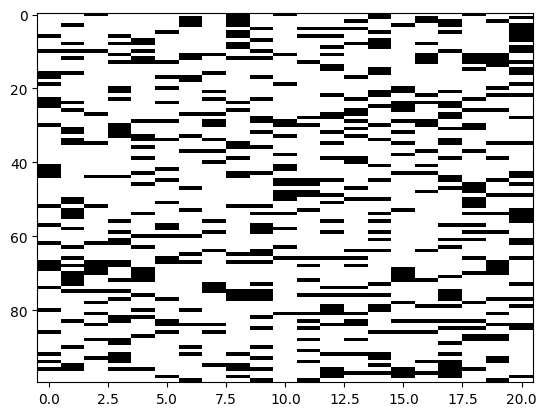

In [267]:
component_samples = jax.vmap(lambda k: naive_autoregressive_decoding(k, x_o), in_axes=0)(jax.random.split(jax.random.PRNGKey(0), 100))
plt.imshow(component_samples, aspect="auto", cmap="gray")

In [268]:
idx = 1
component_mask = component_samples[idx]
component_mask = true_components

In [269]:
logits, latents = model_decoder(component_mask, context=x_o, return_latents=True)

In [270]:
params_sampled = jax.vmap(lambda k: naive_diffusion_sampling(k, latents[None,TRAINABLE_IDX], component_mask))(jax.random.split(jax.random.PRNGKey(1), 1000))

Traced<ShapedArray(float32[])>with<DynamicJaxprTrace(level=2/0)>
(1, 11, 50)
Traced<ShapedArray(float32[])>with<DynamicJaxprTrace(level=3/0)>
(1, 11, 50)
Traced<ShapedArray(float32[])>with<DynamicJaxprTrace(level=4/0)>
(1, 11, 50)


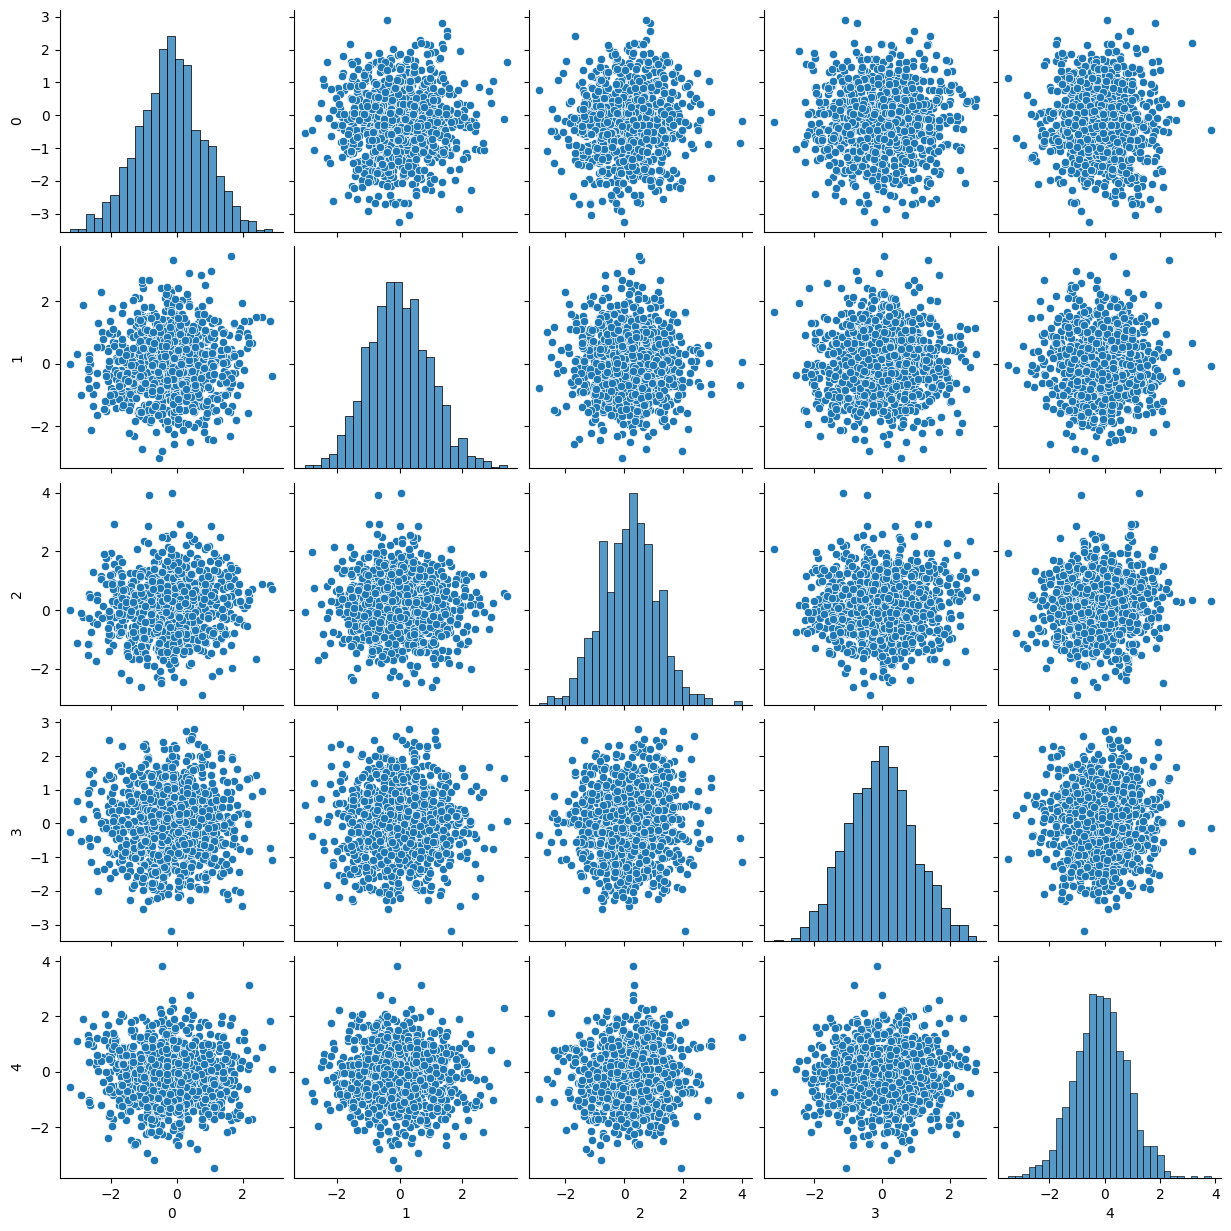

In [271]:
import seaborn as sns
import pandas as pd 
sns.pairplot(data=pd.DataFrame(params_sampled.reshape(-1, NUM_TRAINABLE)[:,:5]), diag_kind="hist")

In [205]:
model_params_flat = unflatten(params_sampled[0])
model_parmas_dict = {PARAMS_IDX[i]: tuple(jnp.split(model_params_flat[i],2)) for i in range(len(model_params_flat))}
model_parmas_dict

{0: (Array([-0.389], dtype=float32), Array([0.894], dtype=float32)),
 1: (Array([1.48], dtype=float32), Array([-0.111], dtype=float32)),
 2: (Array([0.146], dtype=float32), Array([-0.158], dtype=float32)),
 3: (Array([-0.463], dtype=float32), Array([0.907], dtype=float32)),
 4: (Array([-0.42], dtype=float32), Array([1.113], dtype=float32)),
 10: (Array([0.824], dtype=float32), Array([0.943], dtype=float32)),
 11: (Array([-0.13], dtype=float32), Array([-0.095], dtype=float32)),
 12: (Array([0.78], dtype=float32), Array([1.362], dtype=float32)),
 13: (Array([0.608], dtype=float32), Array([-0.008], dtype=float32)),
 14: (Array([0.649], dtype=float32), Array([-0.904], dtype=float32)),
 20: (Array([-0.994], dtype=float32), Array([1.163], dtype=float32))}

In [206]:
x_pred = jax.vmap(lambda x, key : f(component_mask, model_parmas_dict,x, key))( x_o[:,:1],jax.random.split(jax.random.PRNGKey(0), 100))

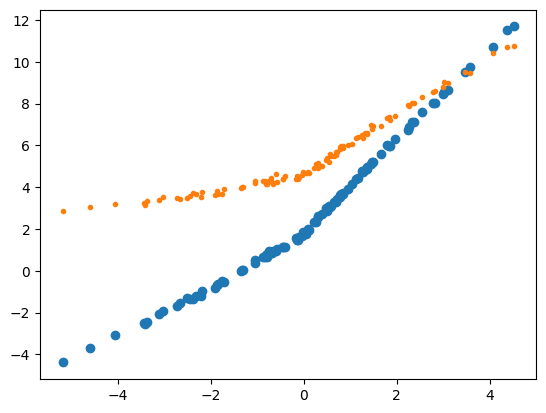

In [207]:
plt.plot(x_o[:,0], x_o[:,1], "o")
plt.plot(x_o[:,0], x_pred, ".")